In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("academic_scores_elementary_district.csv") 

In [6]:
missing_rate = df.isna().mean().sort_values(ascending=False)
print(missing_rate.head(20))

df['missing_frac'] = df.isna().mean(axis=1)
df['missing_count'] = df.isna().sum(axis=1)
print(df[['District','missing_frac','missing_count']].sort_values('missing_frac', ascending=False).head(20))

Science_Proficiency_CWD          0.897638
Math_Proficiency_CWD             0.616798
Science_Proficiency_LowIncome    0.561680
ELA_Proficiency_CWD              0.548556
Science_Proficiency              0.234908
Math_Proficiency_LowIncome       0.182415
ELA_Proficiency_LowIncome        0.108924
Math_Proficiency                 0.024934
ELA_Proficiency                  0.010499
District                         0.000000
dtype: float64
                           District  missing_frac  missing_count
704                   VENICE CUSD 3           0.9              9
394                 LUDLOW CCSD 142           0.9              9
76                 BRUSSELS CUSD 42           0.9              9
424  MEREDOSIA-CHAMBERSBURG CUSD 11           0.9              9
72                  BROOKLYN UD 188           0.9              9
206                 EDINBURG CUSD 4           0.9              9
86                      CAIRO USD 1           0.9              9
2        ACE AMANDLA CHARTER SCHOOL          

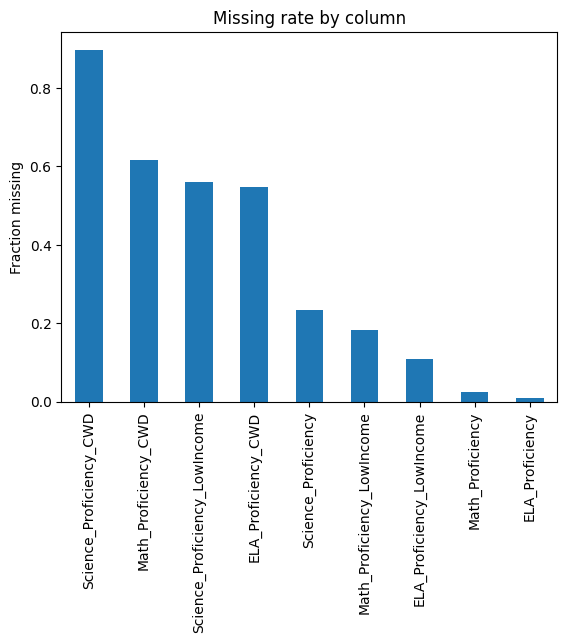

In [19]:
exclude = ["District", "missing_frac", "missing_count"]
cols = [c for c in df.columns if c not in exclude]
miss_rate = df[cols].isna().mean().sort_values(ascending=False)

plt.figure()
miss_rate.plot(kind="bar")
plt.title("Missing rate by column")
plt.ylabel("Fraction missing")
plt.show()

In [20]:
#Group-difference test (MCAR Vs MAR/MNAR)

from scipy import stats

def diff_test(df, target_col, predictor_col):
    m = df[target_col].isna()
    a = df.loc[m, predictor_col].dropna()
    b = df.loc[~m, predictor_col].dropna()
    if len(a) < 5 or len(b) < 5:
        return None
    t, p = stats.ttest_ind(a, b, equal_var=False, nan_policy='omit')
    return p, a.mean(), b.mean()

target = "ELA_Proficiency_LowIncome"
for pred in ["ELA_Proficiency", "Math_Proficiency", "Science_Proficiency"]:
    out = diff_test(df, target, pred)
    print(target, pred, out)


ELA_Proficiency_LowIncome ELA_Proficiency (0.00025127134075544726, 61.87569523809524, 52.29624707371689)
ELA_Proficiency_LowIncome Math_Proficiency (5.698192654229183e-08, 56.797098639455776, 41.932755107574565)
ELA_Proficiency_LowIncome Science_Proficiency (6.287143321712743e-11, 65.63750700280112, 44.2250266086105)


In [23]:
#Multiple imputation
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

num = df.select_dtypes(include=[np.number])

imputer = IterativeImputer(
    random_state=0,
    sample_posterior=True,
    max_iter=20
)

imputed_datasets = []
m = 5
for seed in range(m):
    imp = IterativeImputer(random_state=seed, sample_posterior=True, max_iter=20)
    num_imp = pd.DataFrame(imp.fit_transform(num), columns=num.columns, index=num.index)
    imputed_datasets.append(num_imp)

In [25]:
#Sensitivity Analysis
deltas = [-10, -5, 0, 5, 10]
col = "ELA_Proficiency_LowIncome"
mask = df[col].isna()

base = imputed_datasets[0].copy()
sens_versions = {}

for d in deltas:
    tmp = base.copy()
    tmp.loc[mask, col] = tmp.loc[mask, col] + d
    sens_versions[d] = tmp

In [31]:
#MAR
out_mar = df.copy()
num_cols = num.columns
out_mar[num_cols] = imputed_datasets[0][num_cols]

out_mar.to_csv("district_scores_imputed_MAR.csv", index=False)

#MNAR
out_mnar = df.copy()
out_mnar[num_cols] = imp_num[num_cols]

out_mnar.to_csv("district_scores_imputed_MNAR.csv", index=False)